In [1]:
!pip install requests
!pip install scikit-learn
!pip install duckdb

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Lev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import duckdb
import pandas as pd

DUCKLAKE_URL = "ducklake:https://s3-cache.deadlock-api.com/db-snapshot/public/db_snapshot.ducklake"


with duckdb.connect() as con:
    con.execute("""
        INSTALL ducklake; LOAD ducklake;
        INSTALL httpfs; LOAD httpfs;
        CREATE OR REPLACE SECRET deadlock_s3 (
            TYPE S3, KEY_ID '', SECRET '',
            ENDPOINT 's3-cache.deadlock-api.com', URL_STYLE 'path', USE_SSL true
        );
    """)
    con.execute(f"ATTACH '{DUCKLAKE_URL}' AS db (READ_ONLY)")
    con.execute("USE db.main")

    # Tables are now queryable directly:
    con.sql("SHOW TABLES").show()
    dataset = con.sql( "SELECT match_id, winning_team, hero_id, team, match_mode, average_badge_team0, kills, net_worth " +
        "FROM read_parquet(['s3://db-snapshot/public/match_player/match_player_84.parquet']) " +
        "WHERE average_badge_team0 > 90 and average_badge_team1 > 90 "+
        "AND match_outcome = 'TeamWin' LIMIT 100000" ).df()
    heroes = con.sql("SELECT * FROM heroes").df()
    heroes.index = heroes["id"]

num_heroes = len(heroes)

┌─────────────────────────────┐
│            name             │
│           varchar           │
├─────────────────────────────┤
│ accounts_to_update          │
│ active_matches              │
│ demo_player                 │
│ do_not_use_this_match_info  │
│ hero_leaderboard            │
│ hero_mmr_history            │
│ heroes                      │
│ items                       │
│ leaderboard                 │
│ match_player                │
│ match_salts                 │
│ mmr_history                 │
│ player_card                 │
│ player_match_by_match       │
│ player_match_counts30d_dict │
│ player_match_history        │
└─────────────────────────────┘
            16 rows          



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
dataset

,match_id,winning_team,hero_id,team,match_mode,average_badge_team0,kills,net_worth
0,84058735,Team0,11,Team1,Unranked,104,1,27222
1,84058735,Team0,19,Team0,Unranked,104,7,33041
2,84058735,Team0,8,Team0,Unranked,104,2,30904
3,84058735,Team0,17,Team1,Unranked,104,3,24166
4,84058735,Team0,81,Team1,Unranked,104,0,23009
...,...,...,...,...,...,...,...,...
99995,84449293,Team0,2,Team0,Unranked,101,1,42669
99996,84449293,Team0,76,Team1,Unranked,101,4,32252
99997,84449293,Team0,65,Team1,Unranked,101,12,50877
99998,84449293,Team0,12,Team1,Unranked,101,0,27759


In [4]:
import numpy as np

def data_preprocessing(dataset : pd.DataFrame, heroes : pd.DataFrame):
    hero_ids = heroes["id"].to_numpy() 
    n_features = num_heroes + 4
    
    curr_match_id = "0"
    row = [0 for i in range(n_features)]
    new_data_np = np.array([row])
           
    for i in range(len(dataset)):
        
        match_id = dataset.at[i, "match_id"]
        winning_team = dataset.at[i, "winning_team"]
        hero_id = dataset.at[i, "hero_id"]
        team = dataset.at[i, "team"]
        kills = dataset.at[i, "kills"]
        net_worth = dataset.at[i, "net_worth"]
        
        if curr_match_id != match_id:
            new_data_np = np.append(new_data_np, [row], axis=0)
                
            row = [0 for i in range(n_features)]
            curr_match_id = match_id
            row[0] = curr_match_id
            row[1] = winning_team
            
        hero_row_id = (hero_ids == hero_id).nonzero()[0][0] + 4

        if team == "Team0":
            row[hero_row_id] = 1
            row[2] += int(kills)
            row[3] += int(net_worth)
        else:
            row[hero_row_id] = -1
            row[2] -= int(kills)
            row[3] -= int(net_worth)
        
    new_data_np = np.append(new_data_np, [row], axis=0)
    new_data_np = np.delete(new_data_np, [0,1], axis=0)

    columns = np.append(["match_id", "winning_team", "kills", "net_worth"], hero_ids)

    new_data = pd.DataFrame(new_data_np, columns=columns)
    return new_data
            

In [5]:
dataset_preprocessed = data_preprocessing(dataset, heroes)

target = dataset_preprocessed["winning_team"]
data = dataset_preprocessed.drop(columns=["winning_team", "match_id"]).astype(int)

display(data)

,kills,net_worth,1,2,3,4,6,7,8,10,...,65,66,67,69,72,76,77,79,80,81
0,9,43914,0,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,-1
1,16,45326,0,-1,0,0,0,0,0,0,...,1,1,0,1,0,-1,0,0,-1,0
2,9,30004,0,0,0,1,0,0,0,0,...,0,1,0,0,0,-1,1,1,0,-1
3,9,5676,-1,1,0,1,0,0,0,0,...,-1,0,0,0,0,0,0,0,0,-1
4,31,59123,0,0,1,0,0,0,0,0,...,-1,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8460,-31,-61754,0,0,0,0,0,0,0,0,...,0,1,0,1,0,-1,0,1,1,0
8461,-5,-25786,0,0,0,0,-1,1,0,0,...,0,0,1,0,1,0,0,0,-1,0
8462,2,81735,-1,0,1,0,1,0,-1,0,...,-1,0,0,1,0,0,0,0,0,-1
8463,5,-18289,0,-1,0,0,-1,-1,0,0,...,0,-1,1,0,0,-1,0,-1,0,0


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.2)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

cv_results = cross_validate(
    model,
    data_train,
    target_train,
    return_estimator=True,
    cv=10
)

cv_results_df = pd.DataFrame(cv_results)

results_with_matchup = cv_results_df["test_score"]
display(cv_results_df["test_score"])

0    0.973451
1    0.979351
2    0.974889
3    0.967504
4    0.976366
5    0.977843
6    0.974889
7    0.977843
8    0.977843
9    0.982275
Name: test_score, dtype: float64

In [32]:
# estimators = cv_results["estimator"]
# for estimator in estimators:
#     display(estimator["logisticregression"].coef_)

In [33]:
cv_results = cross_validate(
    model,
    data_train[["kills", "net_worth"]],
    target_train,
    return_estimator=True,
    cv=10
)

cv_results_df = pd.DataFrame(cv_results)

results_without_matchup = cv_results_df["test_score"]
display(cv_results_df["test_score"])

0    0.964602
1    0.966077
2    0.973412
3    0.966027
4    0.964549
5    0.974889
6    0.968981
7    0.966027
8    0.964549
9    0.976366
Name: test_score, dtype: float64

<Axes: ylabel='test_score'>

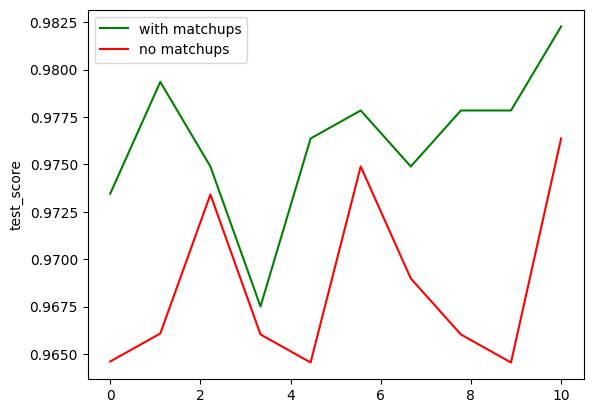

In [40]:
import seaborn as sns
x = np.linspace(0, 10, 10)
sns.lineplot(y=results_with_matchup, x=x, label="with matchups", color="green")
sns.lineplot(y=results_without_matchup, x=x, label="no matchups", color="red")